In [ ]:
!unzip -q MAIN\ PROJECT.zip

In [ ]:
import os

dataset_path = '/content/garbage_classification'

classes = os.listdir(dataset_path)

print("Number of Classes:", len(classes))
print("Classes:", classes)

Number of Classes: 13
Classes: ['biological', 'paper', 'white-glass', 'metal', 'brown-glass', 'trash', 'cardboard', 'clothes', 'green-glass', 'battery', 'plastic', 'shoes', 'organic']


In [ ]:
import os

dataset_path = '/content/garbage_classification'

class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Print results
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

biological: 985 images
paper: 1050 images
white-glass: 775 images
metal: 769 images
brown-glass: 607 images
trash: 697 images
cardboard: 891 images
clothes: 5325 images
green-glass: 629 images
battery: 945 images
plastic: 865 images
shoes: 1977 images
organic: 775 images


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout,GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2  #pretrained model
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.models import Sequential,Model
import seaborn as sns

In [ ]:
image_size=(224,224)
batch_size=32               #Training samples


train_datagen=ImageDataGenerator(
    rescale=1./255,    #normalizes pixels to 0-1
    rotation_range=20,  #rotates image
    zoom_range=0.2,      #zooms image
    horizontal_flip=True,   #flips image
    shear_range=0.2,        #resizes
    validation_split=0.2   #80% train,20% validation
)


In [ ]:

# Training the data
train_generator=train_datagen.flow_from_directory(
    '/content/garbage_classification',   #path of the dataset
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',   #more classes
    subset='training'

)


# testing the data
val_generator=train_datagen.flow_from_directory(
    '/content/garbage_classification',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 13035 images belonging to 13 classes.
Found 3255 images belonging to 13 classes.


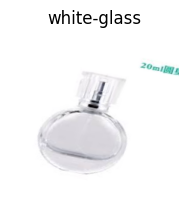

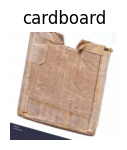

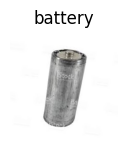

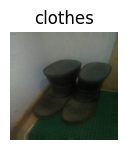

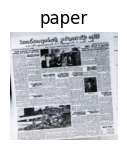

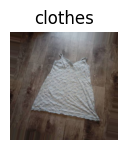

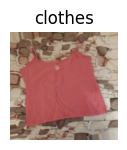

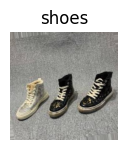

In [ ]:
images,labels=next(train_generator)
class_names=list(train_generator.class_indices.keys())
plt.figure(figsize=(10,8))
for i in range(8):
  plt.subplot(2,4,i+1)
  plt.imshow(images[i])
  plt.title(class_names[np.argmax(labels[i])])
  plt.axis('off')
  plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


# BALANCING THE DATASET
y_train = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.3263125763125763), 1: np.float64(1.272452167122218), 2: np.float64(2.06315289648623), 3: np.float64(1.406300571798468), 4: np.float64(0.23537378114842902), 5: np.float64(1.9894688644688645), 6: np.float64(1.6277472527472527), 7: np.float64(1.6172456575682381), 8: np.float64(1.1936813186813187), 9: np.float64(1.4489773232547798), 10: np.float64(0.6338130895653019), 11: np.float64(1.7969396195202647), 12: np.float64(1.6172456575682381)}


In [ ]:
# using mobile net v3 model

In [ ]:
from tensorflow.keras.applications import MobileNetV3Small

In [ ]:
# STEP 4: Load base model
base_model = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# STEP 5: Freeze layers
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# STEP 6: Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model_v3 = Model(inputs=base_model.input, outputs=output)


In [ ]:
# STEP 7: Compile
model_v3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# STEP 8: Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
# STEP 8: Callbacks
checkpoint_v3 = tf.keras.callbacks.ModelCheckpoint(
    'mobilenetv3_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [ ]:
# STEP 9: Train
history_v3 = model_v3.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint_v3]
)


Epoch 1/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.1084 - loss: 2.6125

408/408 ━━━━━━━━━━━━━━━━━━━━ 224s 504ms/step - accuracy: 0.1115 - loss: 2.5710 - val_accuracy: 0.3272 - val_loss: 2.5610
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 185s 454ms/step - accuracy: 0.1115 - loss: 2.5653 - val_accuracy: 0.0605 - val_loss: 2.5647
Epoch 3/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 183s 450ms/step - accuracy: 0.0576 - loss: 2.5653 - val_accuracy: 0.0605 - val_loss: 2.5643
Epoch 4/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 186s 456ms/step - accuracy: 0.0517 - loss: 2.5653 - val_accuracy: 0.0547 - val_loss: 2.5653


In [ ]:
# STEP 4: Load base model
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# USING MOBILE NET V2

In [ ]:
# STEP 5: Freeze layers
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# STEP 6: Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model_v2 = Model(inputs=base_model.input, outputs=output)

In [ ]:
# STEP 7: Compile
model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_v2 = model_v2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights
)


Epoch 1/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 205s 485ms/step - accuracy: 0.8498 - loss: 0.5006 - val_accuracy: 0.8393 - val_loss: 0.3995
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 191s 467ms/step - accuracy: 0.8574 - loss: 0.4615 - val_accuracy: 0.8387 - val_loss: 0.3870
Epoch 3/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 191s 468ms/step - accuracy: 0.8694 - loss: 0.4243 - val_accuracy: 0.8455 - val_loss: 0.3620
Epoch 4/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 194s 475ms/step - accuracy: 0.8668 - loss: 0.4155 - val_accuracy: 0.8525 - val_loss: 0.3630
Epoch 5/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 194s 476ms/step - accuracy: 0.8769 - loss: 0.3789 - val_accuracy: 0.8621 - val_loss: 0.3573
Epoch 6/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 195s 478ms/step - accuracy: 0.8769 - loss: 0.3711 - val_accuracy: 0.8513 - val_loss: 0.3761
Epoch 7/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 193s 472ms/step - accuracy: 0.8747 - loss: 0.3674 - val_accuracy: 0.8657 - val_loss: 0.3378
Epoch 8/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 189s 464ms/step - accuracy: 0.8766 -

In [ ]:
print("📊 MODEL PERFORMANCE SUMMARY")
print("-"*30)
print(f"Final Train Accuracy: {history_v2.history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy: {history_v2.history['val_accuracy'][-1]:.4f}")
print(f"Best Val Accuracy: {max(history_v2.history['val_accuracy']):.4f}")

📊 MODEL PERFORMANCE SUMMARY
------------------------------
Final Train Accuracy: 0.8962
Final Val Accuracy: 0.8599
Best Val Accuracy: 0.8688


In [ ]:
model_v2.save('mobilenetv2(89% acc).h5')

In [ ]:
model_v2.save('mobilenetv2(89% acc).keras')

In [ ]:
# model testing


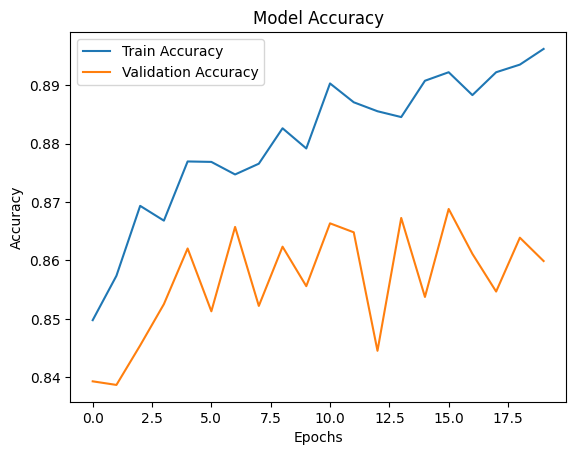

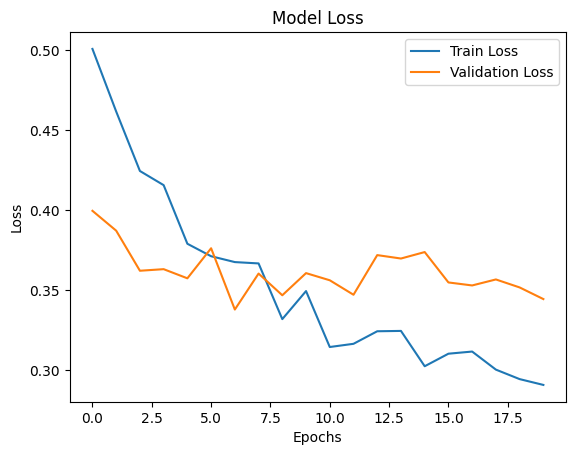

In [ ]:
# Accuracy graph
plt.plot(history_v2.history['accuracy'], label='Train Accuracy')
plt.plot(history_v2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss graph
plt.plot(history_v2.history['loss'], label='Train Loss')
plt.plot(history_v2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Get predictions
y_pred = model_v2.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = val_generator.classes

# Class names
class_names = list(val_generator.class_indices.keys())

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

102/102 ━━━━━━━━━━━━━━━━━━━━ 48s 423ms/step
              precision    recall  f1-score   support

     battery       0.96      0.92      0.94       189
  biological       0.41      0.06      0.10       197
 brown-glass       0.90      0.81      0.85       121
   cardboard       0.93      0.83      0.88       178
     clothes       0.98      0.98      0.98      1065
 green-glass       0.94      0.76      0.84       125
       metal       0.70      0.85      0.76       153
     organic       0.41      0.86      0.56       155
       paper       0.85      0.93      0.89       210
     plastic       0.68      0.80      0.74       173
       shoes       0.95      0.98      0.97       395
       trash       0.94      0.86      0.90       139
 white-glass       0.75      0.70      0.72       155

    accuracy                           0.85      3255
   macro avg       0.80      0.79      0.78      3255
weighted avg       0.86      0.85      0.84      3255



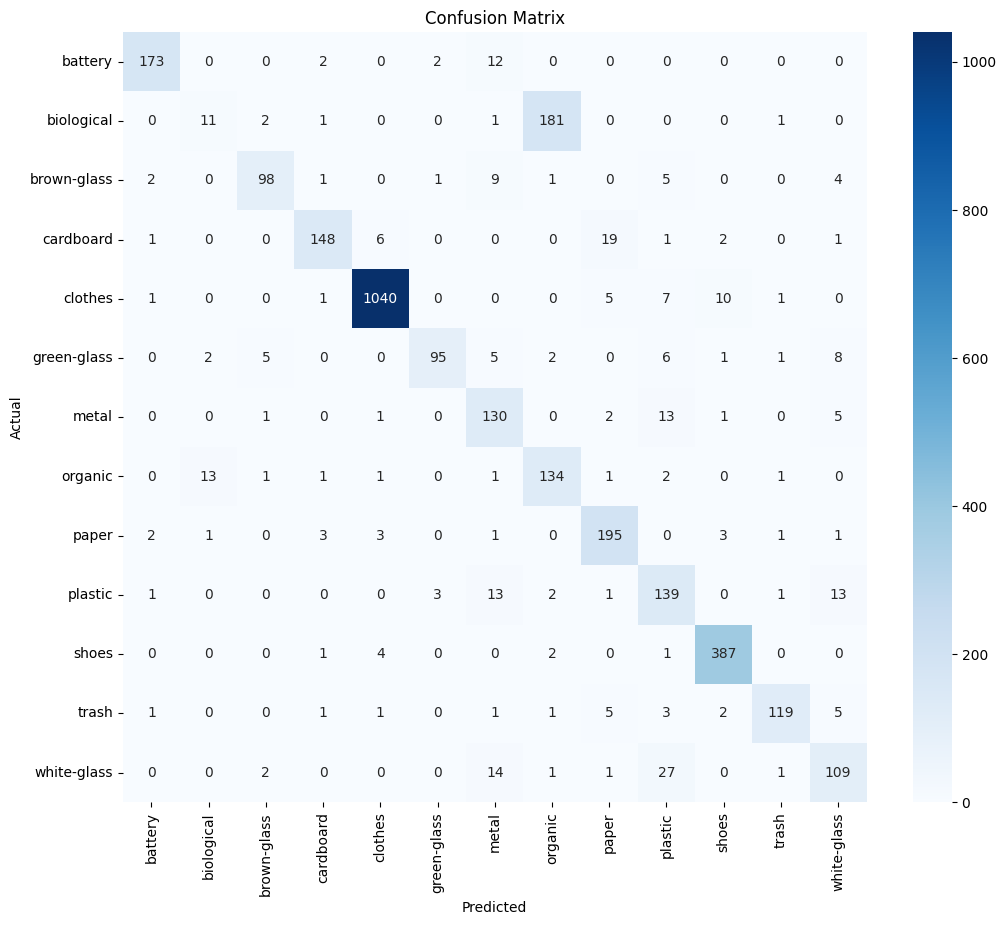

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Load your BEST model (IMPORTANT)
model = load_model('mobilenetv2(89% acc).keras')

# Class names (VERY IMPORTANT → must match training order)
class_names = list(train_generator.class_indices.keys())


def predict_and_check(img_path):

    # 🔹 Load image
    img = image.load_img(img_path, target_size=(224,224))  # MobileNet uses 224
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 🔹 Prediction
    prediction = model.predict(img_array)
    pred_index = np.argmax(prediction)
    confidence = prediction[0][pred_index]
    predicted_label = class_names[pred_index]

    # 🔹 ACTUAL label (from folder name)
    actual_label = os.path.basename(os.path.dirname(img_path))

    # 🔹 Print results
    print(f"📂 Image Path: {img_path}")
    print(f"✅ Predicted Label: {predicted_label}")
    print(f"🎯 Actual Label: {actual_label}")
    print(f"📊 Confidence: {confidence:.2f}")



/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
predict_and_check('/content/garbage_classification/white-glass/white-glass10.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
📂 Image Path: /content/garbage_classification/white-glass/white-glass10.jpg
✅ Predicted Label: white-glass
🎯 Actual Label: white-glass
📊 Confidence: 0.94


In [ ]:
predict_and_check('/content/garbage_classification/green-glass/green-glass10.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
📂 Image Path: /content/garbage_classification/green-glass/green-glass10.jpg
✅ Predicted Label: green-glass
🎯 Actual Label: green-glass
📊 Confidence: 0.73


In [ ]:
history_v2 = model_v2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    class_weight=class_weights
)


Epoch 1/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 261s 583ms/step - accuracy: 0.7380 - loss: 0.9958 - val_accuracy: 0.8224 - val_loss: 0.4516
Epoch 2/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 201s 493ms/step - accuracy: 0.8309 - loss: 0.5849 - val_accuracy: 0.8243 - val_loss: 0.4288
Epoch 3/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 202s 493ms/step - accuracy: 0.8459 - loss: 0.5023 - val_accuracy: 0.8399 - val_loss: 0.4044
Epoch 4/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 200s 489ms/step - accuracy: 0.8536 - loss: 0.4779 - val_accuracy: 0.8501 - val_loss: 0.3785
Epoch 5/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 200s 490ms/step - accuracy: 0.8612 - loss: 0.4329 - val_accuracy: 0.8590 - val_loss: 0.3663
Epoch 6/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 194s 474ms/step - accuracy: 0.8681 - loss: 0.4131 - val_accuracy: 0.8412 - val_loss: 0.3715
Epoch 7/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 200s 492ms/step - accuracy: 0.8694 - loss: 0.3965 - val_accuracy: 0.8473 - val_loss: 0.3641
Epoch 8/25
408/408 ━━━━━━━━━━━━━━━━━━━━ 201s 492ms/step - accuracy: 0.8750 -

In [ ]:
model_v2.save('89.67(acc).h5')

In [ ]:
model_v2.save('89.67(acc).keras')